<a href="https://colab.research.google.com/github/esttefiCarde/Prueba-MineriadeDatosVF/blob/main/Prueba_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos para la Predicción de Salarios en el Ámbito Laboral

integrante: Estephany Cárdenas


Asignatura: Mineria de Datos


Sección: 002D

Profesor: Carlos Humberto Munoz Salgado



## Contexto del dataset y objetivo del análisis



El presente análisis se basa en un dataset relacionado con información laboral, el cual contiene variables como tipo de trabajo, años de experiencia, nivel educacional, cantidad de habilidades, certificaciones y salario.

El objetivo principal de este análisis es explorar y comprender la relación entre distintas variables y el salario, identificando los factores que pueden influir en los ingresos de los trabajadores. Para ello, se realiza un análisis exploratorio de datos (EDA), que incluye visualizaciones, estadísticas descriptivas y análisis de correlación.

Adicionalmente, se aplican técnicas de transformación de variables categóricas a formato numérico, con el fin de facilitar su uso en análisis más avanzados y en futuras etapas de modelamiento dentro del contexto de minería de datos.
https://www.kaggle.com/datasets/hosan707/job-salary-prediction-dataset

In [3]:
# Importamos la librería pandas para manipulación y análisis de datos
import pandas as pd
# Importamos matplotlib para la creación de gráficos
import matplotlib.pyplot as plt
# Importamos seaborn para visualizaciones estadísticas más avanzadas
import seaborn as sns


In [4]:
# Cargamos el dataset desde un archivo CSV y lo almacenamos en el dataframe 'df'
df = pd.read_csv("job_salary.csv")

## Exploración inicial del dataset

En esta sección se realiza una exploración inicial del dataset con el objetivo de comprender su estructura, visualizar los primeros registros y conocer la cantidad de datos y variables disponibles.

In [5]:
# Mostramos las primeras filas del dataset para observar su estructura
# y entender cómo están organizadas las variables
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [44]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [43]:
# Obtenemos la cantidad de filas y columnas del dataset
filas, columnas = df.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 250000
Cantidad de columnas: 10


In [7]:
# Mostramos información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


# Revisión de calidad de datos

En esta sección se analizan las variables numéricas del dataset, con el fin de comprender su comportamiento. Además, se revisa la existencia de valores nulos para evaluar la calidad de los datos.

In [34]:
# Revisamos la cantidad de valores nulos en cada columna del dataset
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [9]:
# Calculamos la cantidad total de valores nulos en el dataset
df.isnull().sum().sum()

np.int64(0)

In [10]:
# Mostramos el tipo de dato de cada columna
df.dtypes

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


In [11]:
# Mostramos los nombres de todas las columnas del dataset
# Esto nos permite identificar las variables disponibles para el análisis
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

### Mapeo de datos

Basado en las características de los datos observadas, cada variable en el dataset se clasifica de la siguiente manera:

| Columna            | Categoría Principal | Subtipo Específico | Descripción y Racionalización                                                                                               |
|:-------------------|:--------------------|:-------------------|:----------------------------------------------------------------------------------------------------------------------------|
| `job_title`        | Categórica          | Nominal            | Representa diferentes títulos de trabajo sin un orden intrínseco.                                                           |
| `experience_years` | Numérica            | Discreta            | Conteo de años de experiencia, toma valores enteros.                                                                        |
| `education_level`  | Categórica          | Ordinal            | Aunque es texto, los niveles educativos tienen una jerarquía clara (e.g., Bachillerato < Maestría < Doctorado).             |
| `skills_count`     | Numérica            | Discreta            | Conteo de habilidades, toma valores enteros.                                                                                |
| `industry`         | Categórica          | Nominal            | Diferentes tipos de industria sin un orden inherente.                                                                       |
| `company_size`     | Categórica          | Ordinal            | El tamaño de la empresa (e.g., 'Small', 'Medium', 'Large') implica una escala con un orden.                                |
| `location`         | Categórica          | Nominal            | Nombres de ubicaciones geográficas, sin un orden natural entre ellas.                                                       |
| `remote_work`      | Categórica          | Nominal (Binaria/Multinomial) | Indica si el trabajo es remoto ('Yes', 'No', 'Hybrid'), las categorías no tienen un orden intrínseco.                   |
| `certifications`   | Numérica            | Discreta            | Conteo de certificaciones, toma valores enteros.                                                                            |
| `salary`           | Numérica            | Continua            | El salario es una medida de cantidad que puede tomar cualquier valor dentro de un rango (aunque aquí se almacene como entero, conceptualmente es continua). |

**Conceptos Clave:**

*   **Categórica:** Representa cualidades o características que se agrupan en categorías.
    *   **Nominal:** Las categorías no tienen un orden intrínseco (ej. `job_title`).
    *   **Ordinal:** Las categorías tienen un orden o jerarquía natural (ej. `education_level`).
*   **Numérica:** Representa cantidades medibles.
    *   **Discreta:** Toman valores enteros específicos (ej. `experience_years`, `skills_count`).
    *   **Continua:** Puede tomar cualquier valor dentro de un rango dado (ej. `salary`).

### Análisis de variables categóricas

In [12]:
# Contamos la frecuencia de cada categoría en la variable 'job_title'
df['job_title'].value_counts()


,count
job_title,
Backend Developer,21125
Cybersecurity Analyst,20959
Product Manager,20950
AI Engineer,20945
Data Scientist,20890
DevOps Engineer,20889
Software Engineer,20876
Data Analyst,20722
Cloud Engineer,20686


In [13]:
# Imprime en pantalla la cantidad de tipos de trabajos distintos (valores únicos)
# que existen en la columna 'job_title' del dataset
print("Cantidad de trabajos distintos:", df['job_title'].nunique())

Cantidad de trabajos distintos: 12


In [14]:
# Contamos la frecuencia de cada nivel educacional
df['education_level'].value_counts()

,count
education_level,
Master,50352
High School,50065
Bachelor,49950
PhD,49857
Diploma,49776


In [15]:
# Imprime en pantalla la cantidad de niveles educacionales distintos (valores únicos)
# presentes en la columna 'education_level' del dataset
print("Cantidad niveles educacionales:", df['education_level'].nunique())

Cantidad niveles educacionales: 5


In [16]:
# Contamos la frecuencia de cada tipo de industria
df['industry'].value_counts()

,count
industry,
Finance,25393
Consulting,25258
Media,25034
Manufacturing,25024
Technology,24903
Government,24901
Healthcare,24898
Education,24889
Telecom,24859


In [17]:
# Imprime en pantalla la cantidad de categorías distintas (valores únicos)
# que existen en la columna 'industry' del dataset
print("Cantidad de industrias:", df['industry'].nunique())

Cantidad de industrias: 10


In [18]:
# Contamos la frecuencia de cada modalidad de trabajo
df['remote_work'].value_counts()

,count
remote_work,
No,83621
Hybrid,83476
Yes,82903


In [19]:
# Imprime en pantalla la cantidad de categorías distintas (valores únicos)
# que existen en la variable 'remote_work', es decir, cuántas modalidades de trabajo hay
print("Cantidad de opciones de trabajo:", df['remote_work'].nunique())

Cantidad de opciones de trabajo: 3


# Estadistica descriptiva de las variables numericas

In [20]:
# Generamos estadísticas descriptivas de las variables numéricas
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


El análisis descriptivo de las variables numéricas permitió observar que el dataset cuenta con 250.000 registros sin valores faltantes. La experiencia laboral presenta un promedio de 10 años, mientras que la cantidad de habilidades también se sitúa en torno a 10. En cuanto a certificaciones, se observa un promedio bajo, cercano a 2.5. Respecto al salario, se evidencia una media de aproximadamente 145.718, con una amplia variabilidad entre los valores mínimos y máximos. Además, el análisis de percentiles muestra que la distribución de los salarios no es uniforme, existiendo diferencias significativas entre los distintos grupos.

In [21]:
# Calculamos la correlación entre variables numéricas para analizar su relación
corr = df[['experience_years', 'skills_count', 'certifications', 'salary']].corr()
corr

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000



Se observa que la variable experiencia presenta una correlación positiva moderada con el salario (0.437), lo que indica que a mayor experiencia laboral, mayor tiende a ser el ingreso.

Por otro lado, variables como la cantidad de habilidades y certificaciones presentan correlaciones positivas débiles con el salario, lo que sugiere que tienen menor influencia en los ingresos

Se observan algunas correlaciones negativas entre variables; sin embargo, estas son cercanas a cero, por lo que no representan una relación significativa entre ellas.



# Distribución de variables numéricas

Aquí se observa cómo se distribuyen los datos numéricos para entender mejor su comportamiento.

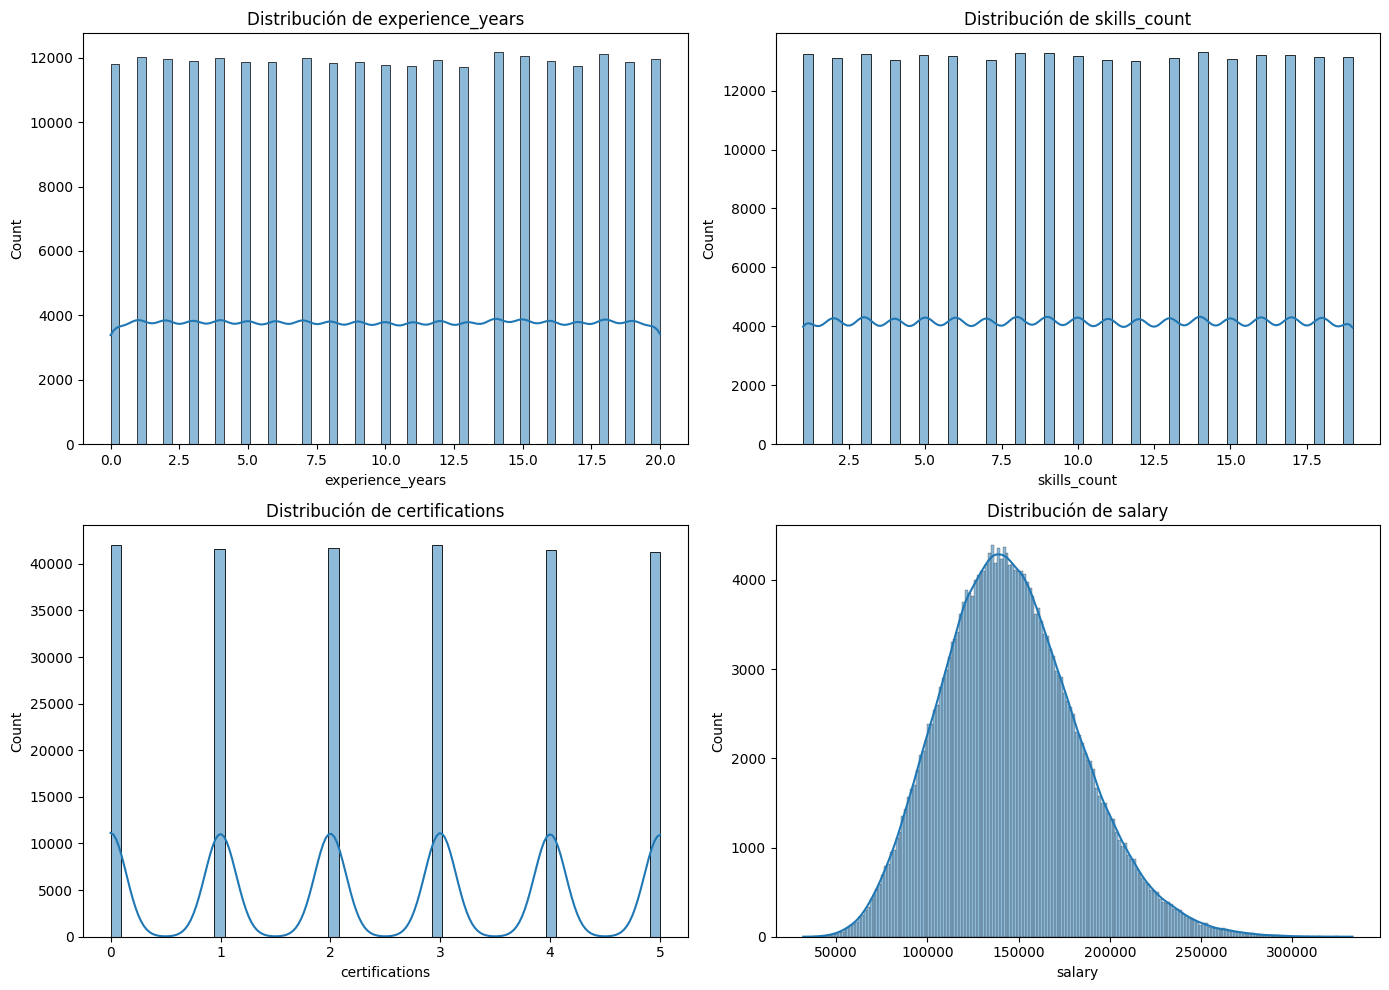

In [22]:
# Lista de variables numéricas que se analizarán
cols_numericas = ['experience_years', 'skills_count', 'certifications', 'salary']

# Definimos el tamaño general de la figura
plt.figure(figsize=(14, 10))

# Creamos un histograma para cada variable numérica
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 2, i)

    # Histograma con curva de densidad para observar la distribución
    sns.histplot(df[col], kde=True)

    # Título de cada gráfico
    plt.title(f'Distribución de {col}')

# Ajustamos el espacio entre gráficos
plt.tight_layout()

# Mostramos los gráficos
plt.show()

### Análisis de distribución de variables numéricas

Con el objetivo de comprender el comportamiento de las variables numéricas del dataset, se analizaron sus distribuciones mediante histogramas acompañados de curvas de densidad. Este análisis permite identificar la forma de los datos, su dispersión y posibles patrones relevantes.

En primer lugar, la variable *experience_years* presenta una distribución relativamente uniforme, lo que indica que los datos están repartidos de manera equilibrada entre los distintos niveles de experiencia. No se observa una concentración significativa en un rango específico, lo que sugiere que el dataset incluye trabajadores con diversos niveles de trayectoria laboral.

De manera similar, la variable *skills_count* también muestra una distribución uniforme. Esto implica que la cantidad de habilidades está distribuida de forma equilibrada entre los individuos, sin predominio de valores bajos o altos. Esta característica favorece el análisis, ya que evita sesgos asociados a la concentración de datos en ciertos niveles.

La variable certifications es discreta, ya que solo toma valores enteros entre 0 y 5. Además, se observa que estos valores están distribuidos de manera equilibrada, es decir, hay una cantidad similar de personas en cada nivel de certificaciones.
distribución relativamente equilibrada
En contraste, la variable *salary* muestra una distribución aproximadamente normal, caracterizada por una mayor concentración de valores en torno a un rango medio y una disminución progresiva hacia los extremos. Esto indica que la mayoría de los trabajadores percibe salarios cercanos al promedio, mientras que los valores muy altos o muy bajos son menos frecuentes.

En conjunto, estas distribuciones evidencian que las variables explicativas (experiencia, habilidades y certificaciones) presentan una buena dispersión y representatividad, lo que favorece la calidad del análisis. Asimismo, la distribución del salario permite identificar un comportamiento típico en torno a valores centrales, facilitando la interpretación de relaciones con otras variables.

## Análisis 1: Relación entre experiencia y salario
Se analiza si los años de experiencia se relacionan con el salario.

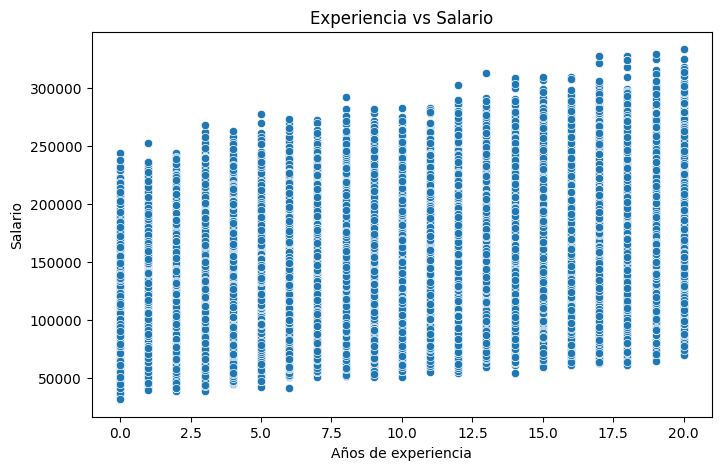

In [23]:
# Creamos una figura para el gráfico y definimos su tamaño
plt.figure(figsize=(8,5))
# Generamos un gráfico de dispersión para analizar la relación entre experiencia y salario
sns.scatterplot(data=df, x='experience_years', y='salary')
# Agregamos título y nombres a los ejes
plt.title("Experiencia vs Salario")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")
# Mostramos el gráfico
plt.show()

Aunque existe una tendencia a que el salario aumente con la experiencia, los datos muestran bastante variabilidad. Esto indica que personas con la misma experiencia pueden tener salarios diferentes, por lo que existen otros factores que también influyen en los ingresos.

## Análisis 2: Nivel educacional y salario
Se compara el salario según el nivel educacional.

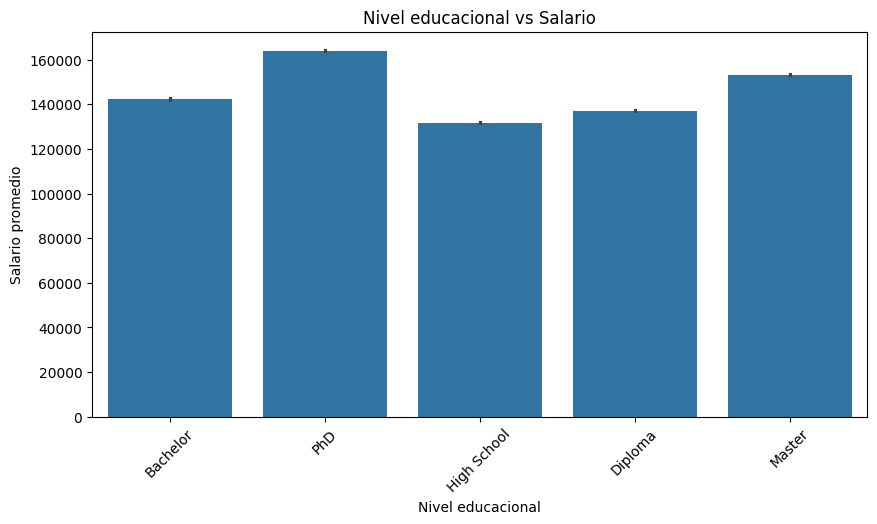

In [24]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(10,5))

# Creamos un gráfico de barras
# En el eje X se muestran los niveles educacionales
# En el eje Y se muestra el salario promedio para cada nivel
sns.barplot(data=df, x='education_level', y='salary')

# Agregamos el título del gráfico
plt.title("Nivel educacional vs Salario")

# Etiqueta del eje X
plt.xlabel("Nivel educacional")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Rotamos las etiquetas del eje X para mejorar la visualización
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

Se observa que el nivel educacional influye en el salario promedio. Los niveles más altos, como PhD (Doctorado) y Master, presentan mayores ingresos en comparación con niveles más bajos como High School. Esto sugiere una relación positiva entre educación y salario.

## Análisis 3: Certificaciones y salario
Se analiza cómo influye la cantidad de certificaciones en el salario.

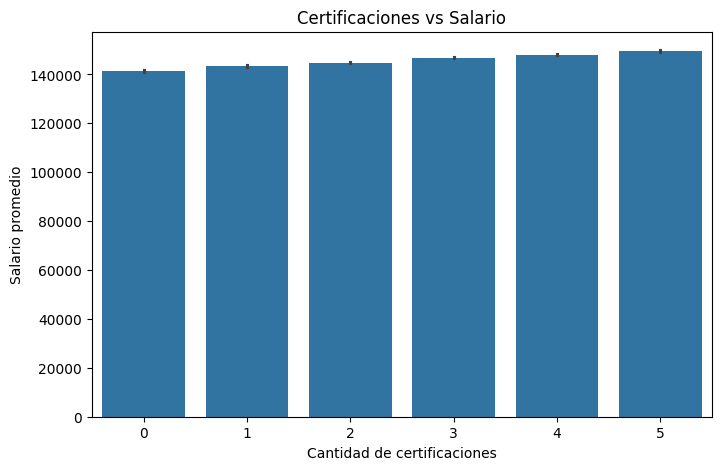

In [25]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(8,5))

# Creamos un gráfico de barras (barplot)
# En el eje X se muestra la cantidad de certificaciones
# En el eje Y se muestra el salario promedio para cada cantidad de certificaciones
sns.barplot(data=df, x='certifications', y='salary')

# Agregamos el título del gráfico
plt.title("Certificaciones vs Salario")

# Etiqueta del eje X
plt.xlabel("Cantidad de certificaciones")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Mostramos el gráfico
plt.show()

Se observa que a medida que aumenta la cantidad de certificaciones, el salario promedio tiende a incrementarse ligeramente.

Sin embargo, la variación no es muy significativa, lo que indica que la influencia de las certificaciones en el salario es relativamente baja en comparación con otras variables.

## Análisis 4: Trabajo remoto y salario
Se compara el salario según la modalidad de trabajo.

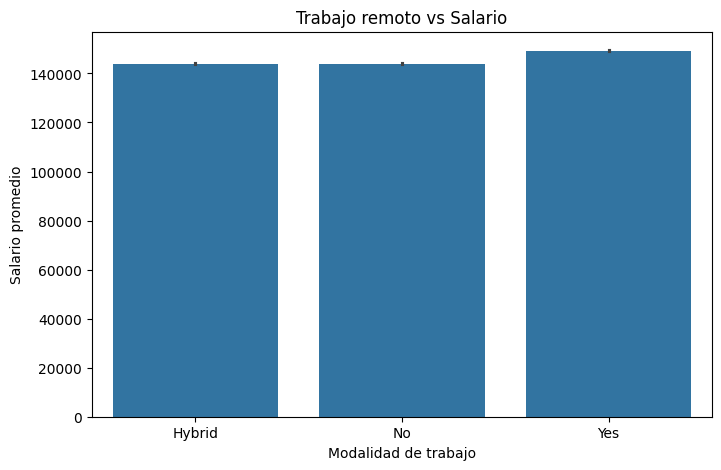

In [26]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(8,5))

# Creamos un gráfico de barras para comparar el salario promedio según la modalidad de trabajo
# En el eje X se muestran las categorías de trabajo remoto (Hybrid, No, Yes)
# En el eje Y se muestra el salario promedio de cada categoría
sns.barplot(data=df, x='remote_work', y='salary')

# Agregamos el título del gráfico
plt.title("Trabajo remoto vs Salario")

# Etiqueta del eje X
plt.xlabel("Modalidad de trabajo")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Mostramos el gráfico
plt.show()

Se observa que el salario promedio es similar entre las distintas modalidades de trabajo (remoto, presencial e híbrido).

Aunque el trabajo remoto presenta un salario ligeramente mayor, la diferencia no es significativa, lo que sugiere que la modalidad de trabajo no tiene un impacto importante en los ingresos.

# Transformación de variables categóricas a variables numéricas

En esta sección se transforman las variables categóricas del dataset a formato numérico mediante técnicas de encoding. Este proceso permite que dichas variables puedan ser utilizadas en análisis estadísticos, como la correlación, y en futuros modelos de datos, facilitando su interpretación y procesamiento.

In [64]:

from sklearn.preprocessing import LabelEncoder  # Importa herramienta para codificar variables

df_nuevo = df.copy()  # Crea una copia del dataset original

# Codifica el nivel educacional a números
le_edu = LabelEncoder()
df_nuevo['education_encoded'] = le_edu.fit_transform(df_nuevo['education_level'])

# Codifica el tamaño de empresa a números
le_size = LabelEncoder()
df_nuevo['company_size_encoded'] = le_size.fit_transform(df_nuevo['company_size'])

# Aplica One Hot Encoding a variables categóricas sin orden
df_nuevo = pd.get_dummies(df_nuevo, columns=['job_title', 'industry', 'location', 'remote_work'], drop_first=False)

# Elimina las columnas originales ya transformadas
df_nuevo = df_nuevo.drop(columns=['education_level', 'company_size'])




Para la transformación de variables categóricas a numéricas, se utilizaron distintos métodos de codificación según el tipo de variable.

En el caso de las variables ordinales, como el nivel educacional y el tamaño de la empresa, se aplicó Label Encoding, ya que estas poseen un orden natural entre sus categorías, lo que permite representarlas adecuadamente mediante valores numéricos.

Por otro lado, para las variables nominales, como el cargo, la industria, la ubicación y la modalidad de trabajo, se utilizó One Hot Encoding. Este método crea variables binarias independientes para cada categoría, evitando así introducir relaciones de orden que no existen en la realidad.

De esta forma, se garantiza una representación adecuada de los datos para su posterior análisis.

In [46]:
# Mostramos las primeras filas del nuevo dataset para verificar los cambios
df_nuevo.head()

,experience_years,skills_count,certifications,salary,education_encoded,company_size_encoded,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,10,2,2,109413,0,2,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,5,17,0,93764,0,3,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,4,2,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,19,13,0,189123,4,2,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,0,1,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [60]:
# Obtenemos la cantidad de filas y columnas del nuevo dataset
filas, columnas = df_nuevo.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 250000
Cantidad de columnas: 41


### Matriz de correlación ampliada con variables categóricas transformadas

Se incluyen variables categóricas previamente transformadas mediante técnicas de encoding.

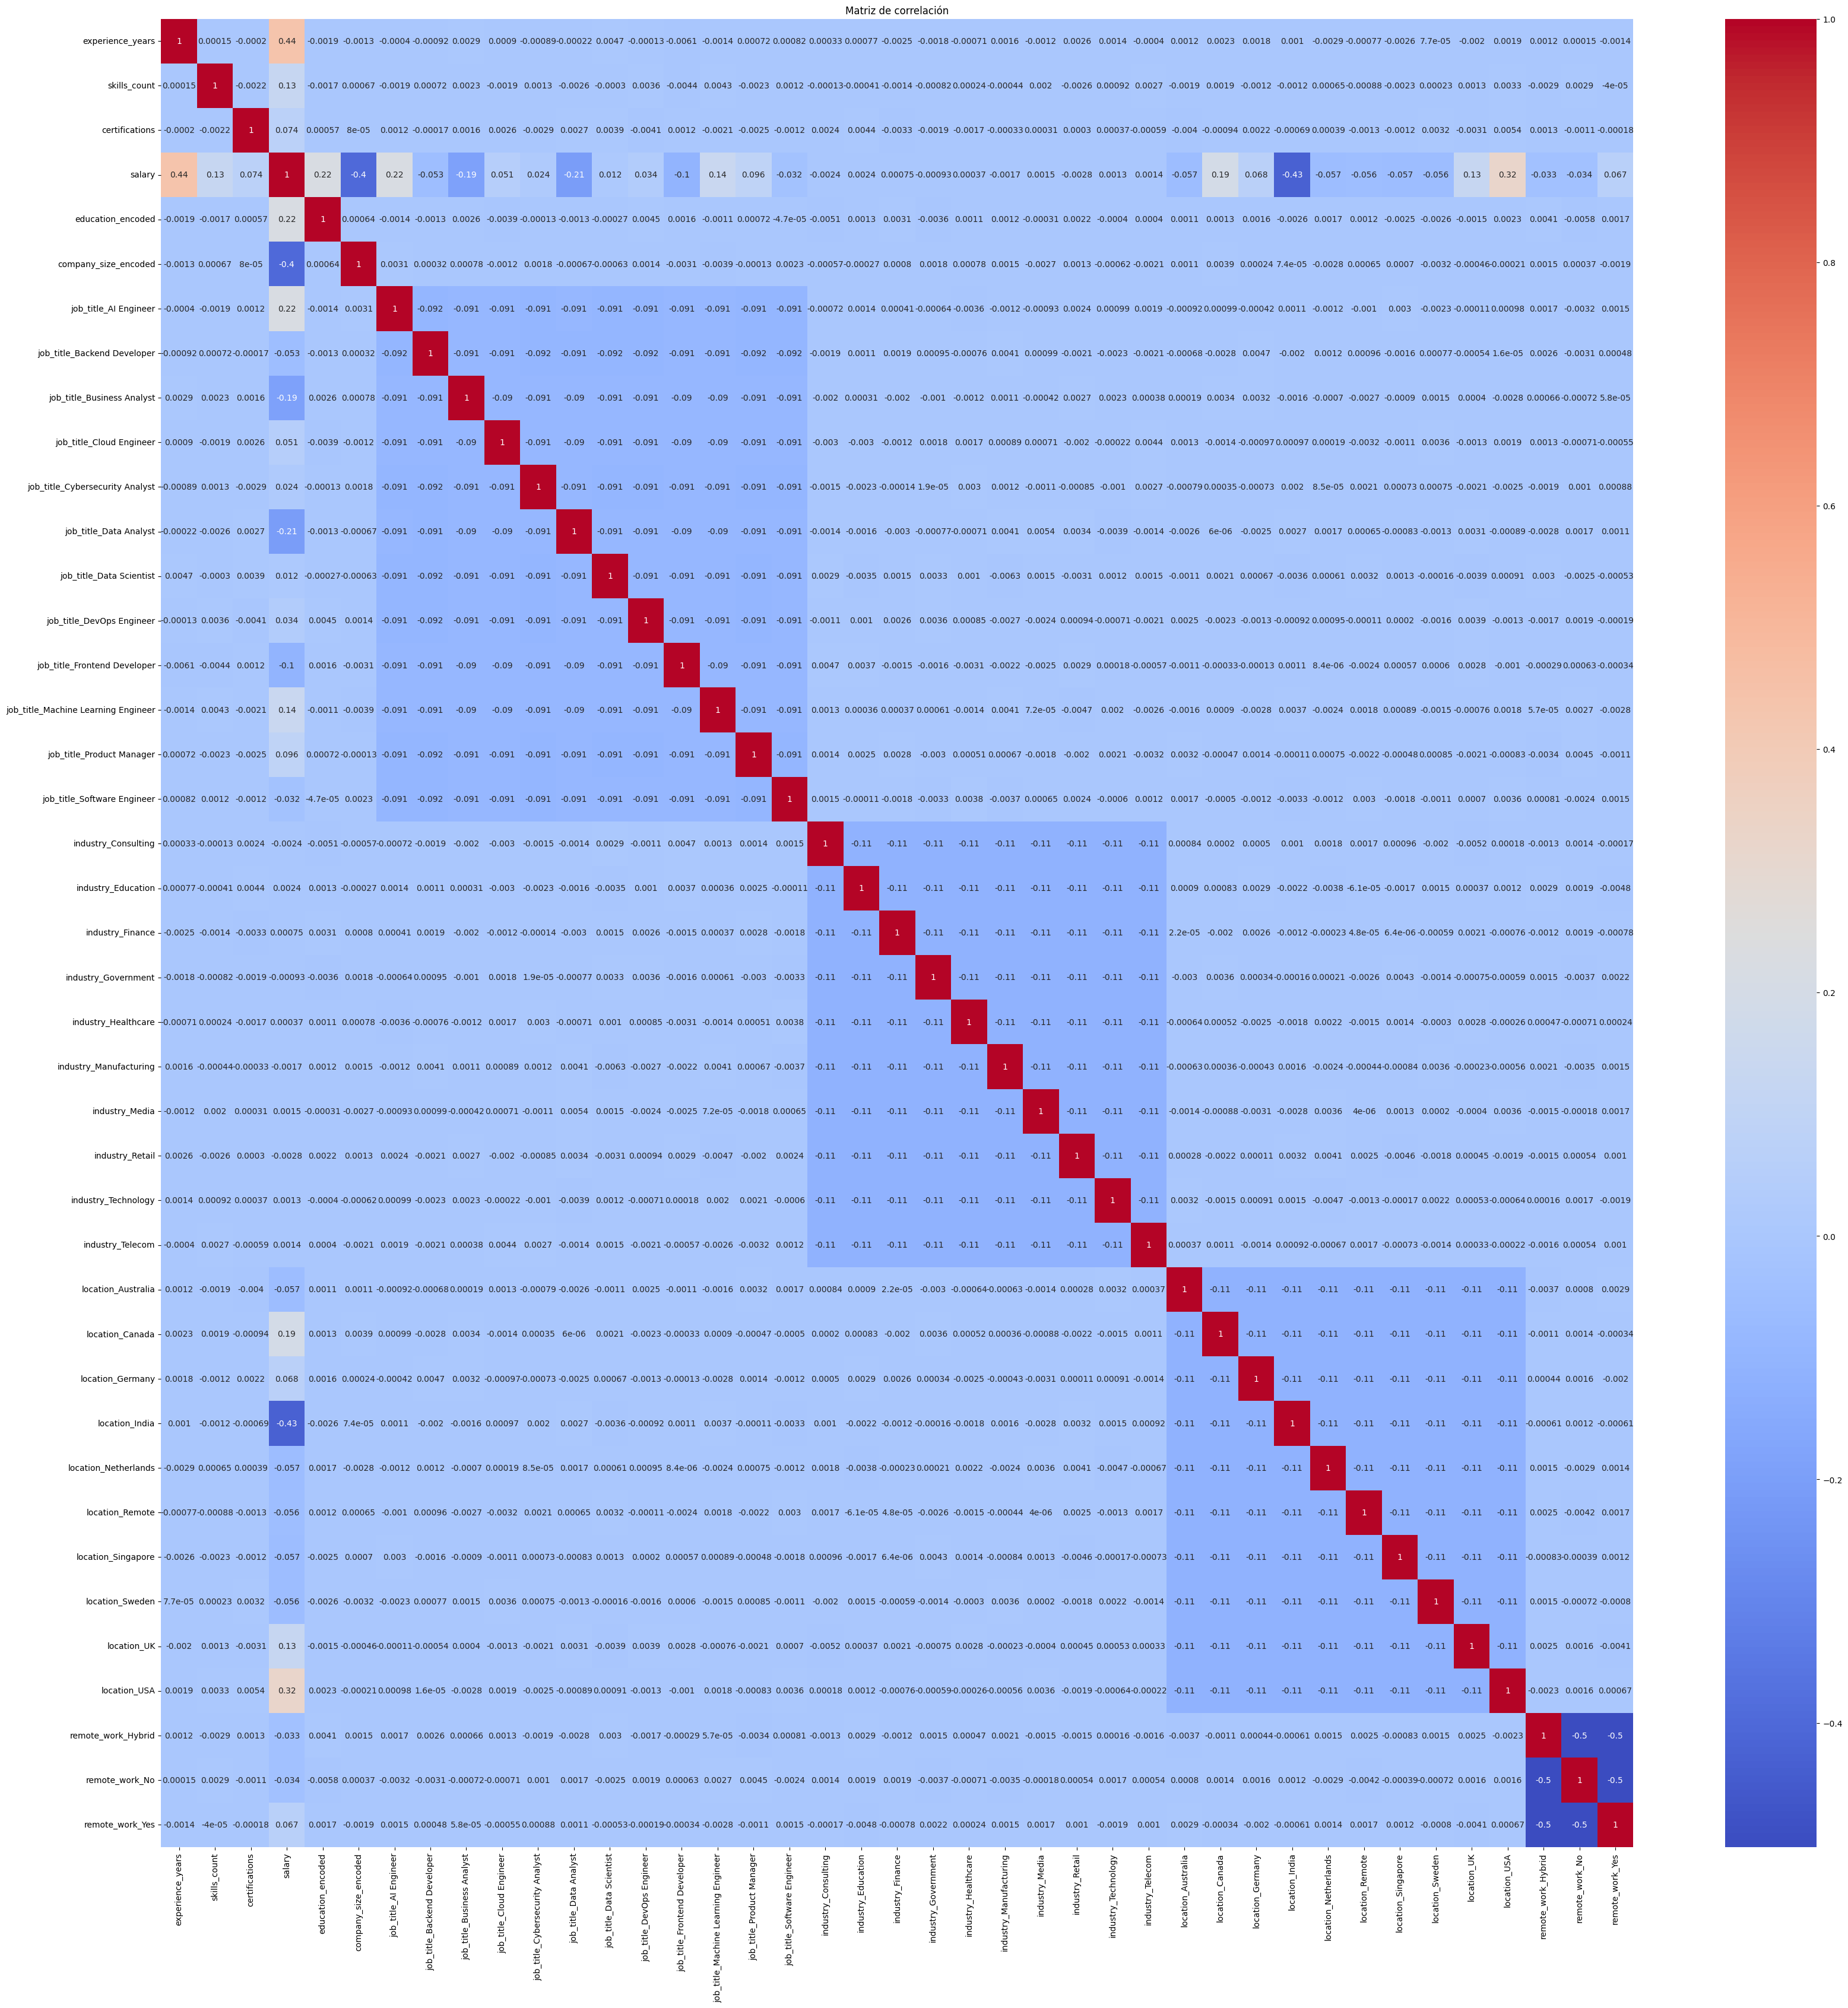

In [59]:
from numpy import true_divide
# Calculamos la matriz de correlación del dataset 'df_nuevo'
# Se consideran únicamente variables numéricas, incluyendo aquellas que fueron transformadas desde variables categóricas mediante encoding
corr_matrix = df_nuevo.corr(numeric_only=True)
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(40, 40))

# Agregamos un título al gráfico
plt.title("Matriz de correlación")
# Creamos el heatmap (mapa de calor) para visualizar la correlación
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# Mostramos el gráfico en pantalla
plt.show()

La matriz de correlación permite observar qué tan relacionadas están las variables entre sí. Los valores van desde -1 hasta 1: mientras más cerca de 1, más positiva es la relación; mientras más cerca de -1, más negativa; y mientras más cerca de 0, menor relación existe.

En esta matriz se observa que la variable que presenta mayor relación con el salario es experience_years, con una correlación aproximada de 0.44. Esto indica una relación positiva moderada, a mayor experiencia laboral, el salario tiende a aumentar.

También se observa que education_encoded tiene una relación positiva con el salario, aproximadamente de 0.22. Esto sugiere que el nivel educacional influye en los ingresos, aunque con menor fuerza que la experiencia.

Por otra parte, skills_count y certifications presentan correlaciones más bajas con el salario, aproximadamente 0.13 y 0.07 respectivamente. Esto significa que, aunque pueden tener cierta influencia, su relación con el salario es débil dentro de este dataset.

En el caso de las variables transformadas mediante One Hot Encoding, como remote_work y location, aparecen algunas correlaciones negativas entre categorías. Esto es normal, ya que estas variables funcionan de forma excluyente: por ejemplo, si una persona pertenece a una modalidad de trabajo, no puede pertenecer al mismo tiempo a otra. Por eso, algunas categorías aparecen con valores negativos entre sí.

Respecto a las ubicaciones, se observan diferencias según el país. Algunas ubicaciones presentan correlación positiva con el salario, mientras que otras presentan correlación negativa. Esto sugiere que la ubicación puede influir en el salario, aunque no todas las regiones o países tienen el mismo efecto.

En general, la matriz muestra que no existe una sola variable que explique completamente el salario. La experiencia es el factor más relevante, seguida por el nivel educacional, pero el salario parece depender de una combinación de factores como experiencia, educación, modalidad de trabajo, ubicación y otras características laborales.

### Identificación de outliers en variables numéricas

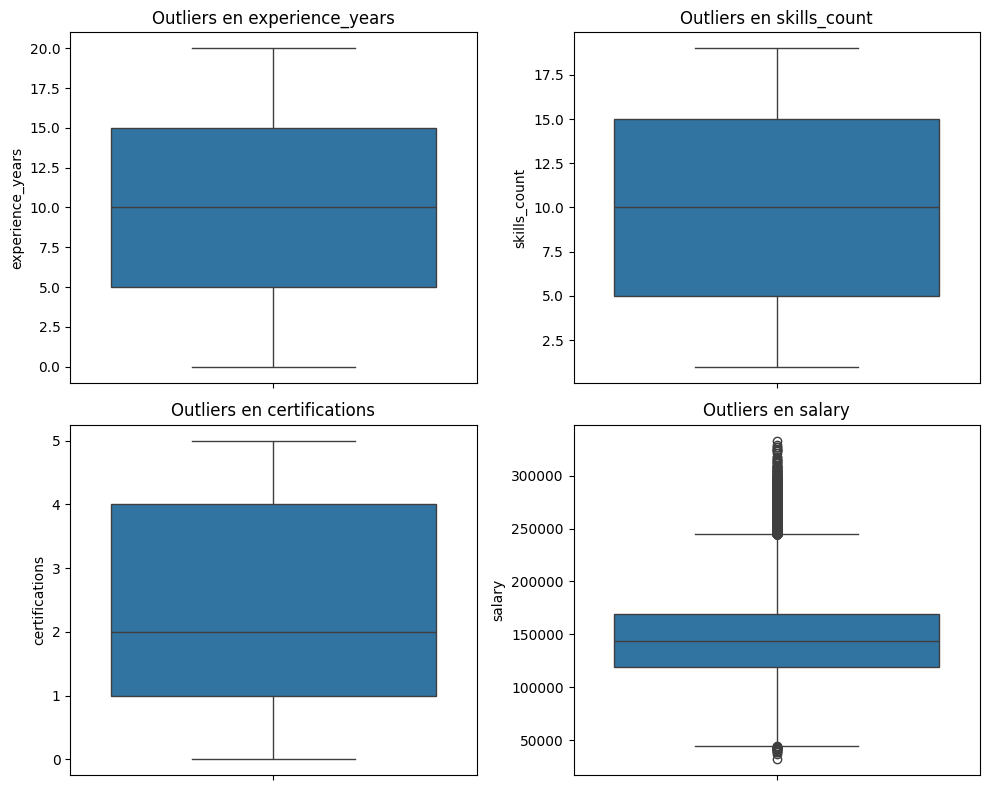

In [40]:
# Definimos las columnas numéricas que queremos analizar
cols_numericas = ['experience_years', 'skills_count', 'certifications', 'salary']

# Creamos una figura general donde irán todos los gráficos
# figsize define el tamaño de la imagen (ancho, alto)
plt.figure(figsize=(10, 8))

# Recorremos cada columna junto con su posición (i)
for i, col in enumerate(cols_numericas, 1):

    # 2 filas, 2 columnas, posición i
    plt.subplot(2, 2, i)

    # Creamos el boxplot (gráfico de caja) de la variable actual
    # Usamos 'y' para que el gráfico sea vertical
    sns.boxplot(y=df[col])

    # Agregamos un título a cada gráfico
    plt.title(f'Outliers en {col}')

# Ajustamos automáticamente los espacios entre gráficos
# Evita que se sobrepongan títulos o ejes
plt.tight_layout()

# Mostramos la figura completa con todos los gráficos
plt.show()

En los gráficos tipo boxplot se observa la distribución de las variables numéricas y la presencia de posibles valores atípicos (outliers).

En el caso de *experience_years*, se aprecia una distribución relativamente uniforme, con valores que se concentran entre aproximadamente 5 y 15 años de experiencia, sin evidencia de outliers significativos. Esto indica que la mayoría de los datos se encuentran dentro de un rango esperado.

De manera similar, la variable *skills_count* presenta una distribución equilibrada, con valores concentrados en torno al rango medio, sin presencia de valores atípicos, lo que sugiere consistencia en la cantidad de habilidades reportadas.

Para la variable *certifications*, se observa una menor dispersión de los datos, concentrándose principalmente entre 1 y 4 certificaciones. Tampoco se identifican outliers relevantes, lo que indica estabilidad en esta variable.

Por otro lado, la variable *salary* presenta una mayor dispersión y una clara presencia de valores atípicos, tanto en la parte superior como inferior. Esto indica que existen salarios significativamente más altos y más bajos que el promedio, lo que refleja una mayor variabilidad en los ingresos dentro del dataset.

En general, se concluye que la variable salario es la que presenta mayor variabilidad y presencia de valores extremos, mientras que las demás variables muestran distribuciones más estables y sin outliers significativos.

### Estandarización de variables numéricas

La estandarización transforma los datos para que tengan una escala común, donde los valores cercanos a 0 representan el promedio, los positivos están sobre el promedio y los negativos por debajo.

In [42]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas numéricas a estandarizar
cols_a_escalar = ['experience_years', 'skills_count', 'certifications', 'salary']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Creamos una copia del dataset para no modificar el original
df_escalado = df.copy()

# 4. Aplicamos la estandarización
df_escalado[cols_a_escalar] = scaler.fit_transform(df_escalado[cols_a_escalar])

# 5. Verificamos los resultados
print("Primeras filas con datos estandarizados:")
print(df_escalado[cols_a_escalar].head())

Primeras filas con datos estandarizados:
   experience_years  skills_count  certifications    salary
0         -0.000892     -1.459647       -0.288272 -0.970520
1         -0.825894      1.277940       -1.460281 -1.388854
2          1.319111     -1.094636       -0.874276  0.064289
3          1.484112      0.547917       -1.460281  1.160315
4          0.824110     -0.547118       -1.460281  0.517295


A partir de los valores estandarizados, es posible interpretar cada observación en relación con el promedio de las variables.

Por ejemplo, en la primera fila se observa que el valor de *salary* es -0.97, lo que indica que este salario se encuentra por debajo del promedio del dataset. Además, el valor de *skills_count* es -1.45, lo que sugiere que esta persona posee una cantidad de habilidades considerablemente menor al promedio.

En la segunda fila, el valor de *salary* es -1.38, reflejando un salario aún más bajo que el promedio. A su vez, el valor de *certifications* es -1.46, lo que indica que también cuenta con menos certificaciones que la mayoría de los individuos del dataset.

Por otro lado, en la tercera fila, el valor de *experience_years* es 1.31, lo que representa un nivel de experiencia superior al promedio. Sin embargo, su *salary* es cercano a 0 (0.06), lo que indica que su ingreso se encuentra en torno al promedio, evidenciando que una mayor experiencia no siempre se traduce directamente en un salario más alto.

Finalmente, en la cuarta fila, se observa un valor de *salary* de 1.16, lo que indica un salario superior al promedio. Este caso también presenta un valor positivo en *experience_years* (1.48), lo que sugiere que una mayor experiencia podría estar asociada a mayores ingresos en ciertos casos.

# Conclusión
En conclusión, el análisis exploratorio permitió identificar que la experiencia laboral es el factor con mayor relación con el salario, seguida en menor medida por el nivel educacional. No obstante, los resultados evidencian que el salario no depende de una única variable, sino de la interacción de múltiples factores, como habilidades, certificaciones, ubicación y características del trabajo, lo que refleja la complejidad del comportamiento de los ingresos en el contexto laboral.